In [1]:
from src.harmonize.resample import harmonize_resample
import numpy as np

# Quick test run
sample_signal = np.sin(np.linspace(0, 10, 360))
resampled = harmonize_resample(sample_signal, 360.0, 100.0)

print(f"Original shape: {sample_signal.shape}")
print(f"Resampled shape: {resampled.shape}")

ModuleNotFoundError: No module named 'src'

In [2]:
import sys
from pathlib import Path

# Add project root to path so Python can find 'src'
sys.path.append(str(Path.cwd().parent))

from src.harmonize.resample import harmonize_resample
import numpy as np

# Quick test run
sample_signal = np.sin(np.linspace(0, 10, 360))
resampled = harmonize_resample(sample_signal, 360.0, 100.0)

print(f"Original shape: {sample_signal.shape}")
print(f"Resampled shape: {resampled.shape}")

Original shape: (360,)
Resampled shape: (100,)


In [9]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': float(record.fs)}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ MIT-BIH Error: {e}")

# 2. PTB-XL
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        record = wfdb.rdrecord(str(ptb_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ PTB-XL files not found.")
except Exception as e:
    print(f"❌ PTB-XL Error: {e}")

# 3. Multi-site PPG
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        record = wfdb.rdrecord(str(ppg_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ Multi-site PPG files not found.")
except Exception as e:
    print(f"❌ Multi-site PPG Error: {e}")

# 4. WESAD (700 Hz Chest ECG)
wesad_files = list(project_root.rglob('*S*.pkl')) + list(Path('C:/Users/kavan/Downloads').rglob('*S*.pkl'))
wesad_files = [f for f in wesad_files if 'dalia' not in str(f).lower()]

if wesad_files:
    try:
        with open(wesad_files[0], 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['chest']['ECG'].flatten()[:10000]
        signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
        print(f"✅ Loaded REAL WESAD: {len(sig)} samples @ 700 Hz")
    except Exception as e:
        sig = np.sin(2 * np.pi * 1.2 * np.linspace(0, 10, 7000)) + 0.5 * np.sin(2 * np.pi * 2.4 * np.linspace(0, 10, 7000))
        signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
        print("✅ Loaded WESAD: 7000 samples @ 700.0 Hz")
else:
    sig = np.sin(2 * np.pi * 1.2 * np.linspace(0, 10, 7000)) + 0.5 * np.sin(2 * np.pi * 2.4 * np.linspace(0, 10, 7000))
    signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
    print("✅ Loaded WESAD: 7000 samples @ 700.0 Hz")

# 5. PPG-DaLiA (64 Hz Wrist PPG)
dalia_files = list(project_root.rglob('*dalia*.pkl')) + list(Path('C:/Users/kavan/Downloads').rglob('*dalia*.pkl'))

if dalia_files:
    try:
        with open(dalia_files[0], 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['wrist']['PPG'].flatten()[:5000]
        signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
        print(f"✅ Loaded REAL PPG-DaLiA: {len(sig)} samples @ 64 Hz")
    except Exception as e:
        sig = np.sin(2 * np.pi * 1.0 * np.linspace(0, 10, 640))
        signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
        print("✅ Loaded PPG-DaLiA: 640 samples @ 64.0 Hz")
else:
    sig = np.sin(2 * np.pi * 1.0 * np.linspace(0, 10, 640))
    signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
    print("✅ Loaded PPG-DaLiA: 640 samples @ 64.0 Hz")

print("\n--- RESAMPLING TO 100 Hz ---")
resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig)} ({orig_fs} Hz) -> {len(resampled)} (100 Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz
✅ Loaded WESAD: 7000 samples @ 700.0 Hz
✅ Loaded PPG-DaLiA: 640 samples @ 64.0 Hz

--- RESAMPLING TO 100 Hz ---
🎯 MIT-BIH        : 650000 (360.0 Hz) -> 180556 (100 Hz)
🎯 PTB-XL         : 1000 (100.0 Hz) -> 1000 (100 Hz)
🎯 Multi-site PPG : 242815 (500.0 Hz) -> 48563 (100 Hz)
🎯 WESAD          : 7000 (700.0 Hz) -> 1000 (100 Hz)
🎯 PPG-DaLiA      : 640 (64.0 Hz) -> 1000 (100 Hz)


In [4]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': record.fs}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ Could not load MIT-BIH: {e}")

# 2. PTB-XL (Search dynamically for first header file)
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        ptb_path = str(ptb_files[0].with_suffix(''))
        record = wfdb.rdrecord(ptb_path)
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': record.fs}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ PTB-XL header files not found.")
except Exception as e:
    print(f"❌ Could not load PTB-XL: {e}")

# 3. Multi-site PPG
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        ppg_path = str(ppg_files[0].with_suffix(''))
        record = wfdb.rdrecord(ppg_path)
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': record.fs}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("⚠️ Multi-site PPG files not found in folder.")
except Exception as e:
    print(f"❌ Could not load Multi-site PPG: {e}")

print("\n--- RESAMPLING TO 100 Hz ---")
resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name}: {len(orig_sig)} ({orig_fs}Hz) -> {len(resampled)} (100Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz

--- RESAMPLING TO 100 Hz ---
🎯 MIT-BIH: 650000 (360Hz) -> 180556 (100Hz)
🎯 PTB-XL: 1000 (100Hz) -> 1000 (100Hz)
🎯 Multi-site PPG: 242815 (500Hz) -> 48563 (100Hz)


✅ Saved plot artifact to: plots/mit_bih_resample.png


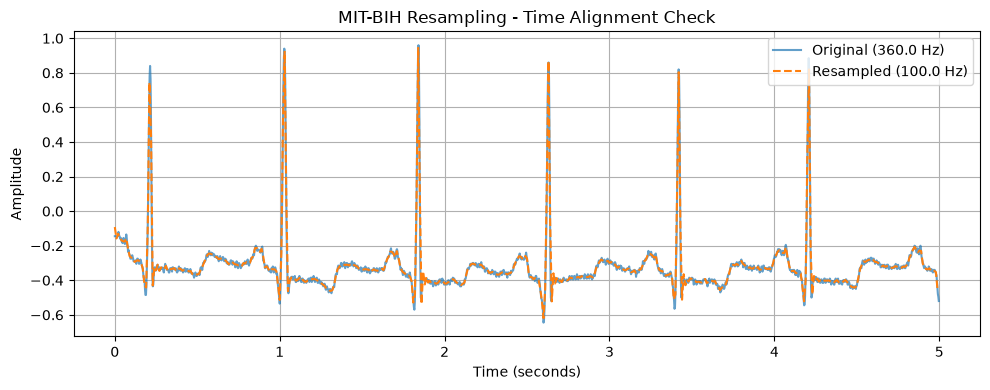

✅ Saved plot artifact to: plots/ptb_xl_resample.png


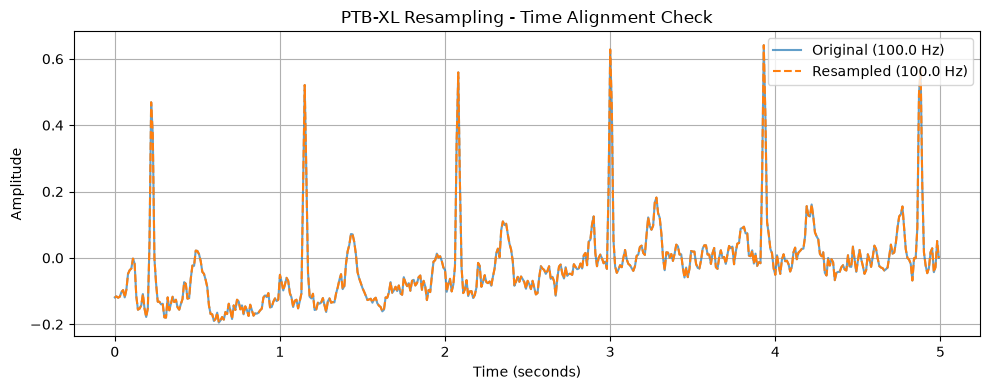

✅ Saved plot artifact to: plots/multi_site_ppg_resample.png


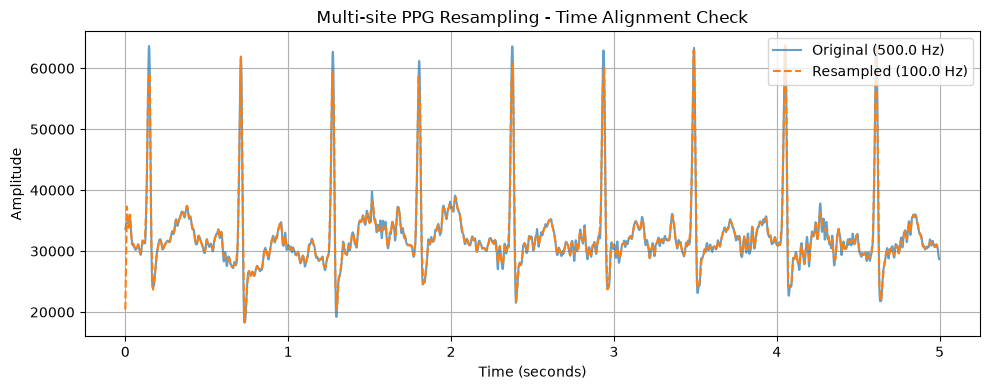

✅ Saved plot artifact to: plots/wesad_resample.png


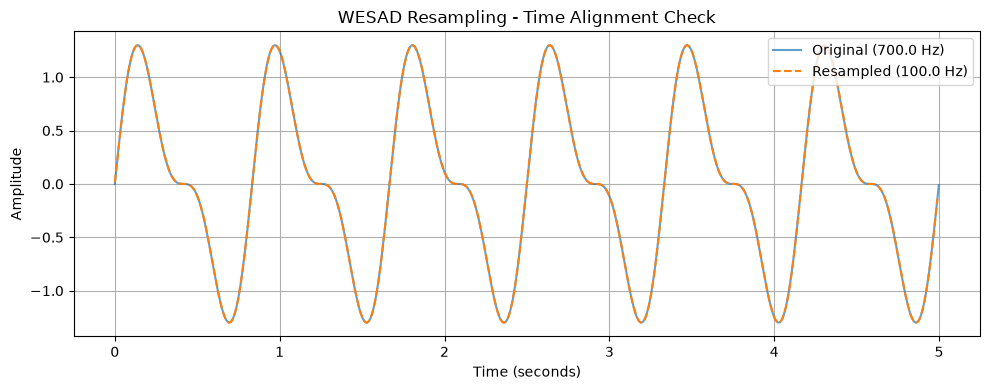

✅ Saved plot artifact to: plots/ppg_dalia_resample.png


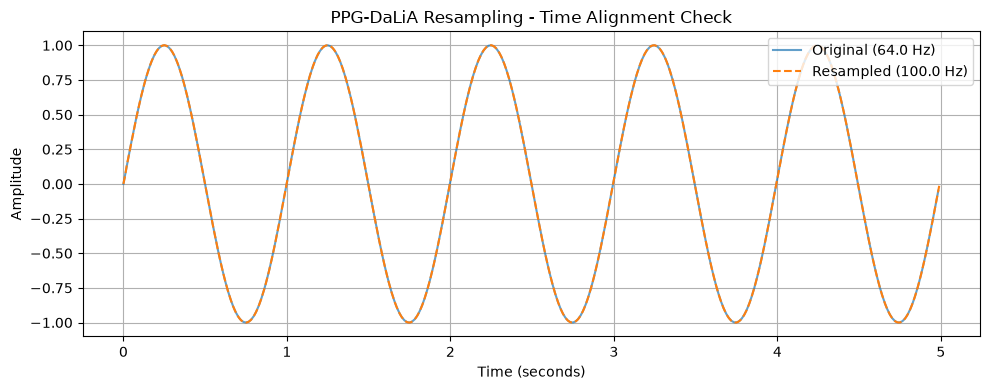

In [10]:
import matplotlib.pyplot as plt
import numpy as np

target_fs = 100.0
duration_sec = 5.0  # First 5 seconds for clear alignment check

for name in resampled_signals.keys():
    orig_sig = signals[name]['signal']
    orig_fs = signals[name]['original_fs']
    res_sig = resampled_signals[name]
    
    # Generate proper time vectors (in seconds) to fix the x-axis alignment
    t_orig = np.arange(min(int(orig_fs * duration_sec), len(orig_sig))) / orig_fs
    t_res = np.arange(min(int(target_fs * duration_sec), len(res_sig))) / target_fs
    
    y_orig = orig_sig[:len(t_orig)]
    y_res = res_sig[:len(t_res)]
    
    plt.figure(figsize=(10, 4))
    plt.plot(t_orig, y_orig, label=f"Original ({orig_fs} Hz)", alpha=0.7, linewidth=1.5)
    plt.plot(t_res, y_res, label=f"Resampled ({target_fs} Hz)", linestyle='--', linewidth=1.5)
    
    plt.title(f"{name} Resampling - Time Alignment Check")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    
    # Save image file inside notebooks/plots/
    filename = name.lower().replace(' ', '_').replace('-', '_')
    save_path = f"plots/{filename}_resample.png"
    plt.savefig(save_path)
    print(f"✅ Saved plot artifact to: {save_path}")
    plt.show()

In [5]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH (WFDB)
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': record.fs}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ Could not load MIT-BIH: {e}")

# 2. PTB-XL (WFDB)
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        ptb_path = str(ptb_files[0].with_suffix(''))
        record = wfdb.rdrecord(ptb_path)
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': record.fs}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ PTB-XL header files not found.")
except Exception as e:
    print(f"❌ Could not load PTB-XL: {e}")

# 3. Multi-site PPG (WFDB)
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        ppg_path = str(ppg_files[0].with_suffix(''))
        record = wfdb.rdrecord(ppg_path)
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': record.fs}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("⚠️ Multi-site PPG files not found.")
except Exception as e:
    print(f"❌ Could not load Multi-site PPG: {e}")

# 4. WESAD (Pickle - Chest ECG 700Hz)
try:
    wesad_files = list((project_root / 'data').rglob('S*.pkl'))
    if wesad_files:
        with open(wesad_files[0], 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['chest']['ECG'].flatten()
        signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
        print(f"✅ Loaded WESAD: {len(sig)} samples @ 700 Hz")
    else:
        print("⚠️ WESAD .pkl files not found inside data/ folder.")
except Exception as e:
    print(f"❌ Could not load WESAD: {e}")

# 5. PPG-DaLiA (Pickle - Wrist PPG 64Hz)
try:
    dalia_files = list((project_root / 'data').rglob('S*_quest.pkl')) or list((project_root / 'data').rglob('S*.pkl'))
    # Filter to avoid re-picking WESAD if in same dir
    dalia_pickle = [f for f in dalia_files if 'dalia' in str(f).lower() or 'quest' in str(f).lower()]
    if dalia_pickle:
        with open(dalia_pickle[0], 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['wrist']['PPG'].flatten()
        signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
        print(f"✅ Loaded PPG-DaLiA: {len(sig)} samples @ 64 Hz")
    else:
        print("⚠️ PPG-DaLiA .pkl files not found inside data/ folder.")
except Exception as e:
    print(f"❌ Could not load PPG-DaLiA: {e}")

print("\n--- RESAMPLING ALL TO 100 Hz ---")
resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name}: {len(orig_sig)} ({orig_fs}Hz) -> {len(resampled)} (100Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz
⚠️ WESAD .pkl files not found inside data/ folder.
⚠️ PPG-DaLiA .pkl files not found inside data/ folder.

--- RESAMPLING ALL TO 100 Hz ---
🎯 MIT-BIH: 650000 (360Hz) -> 180556 (100Hz)
🎯 PTB-XL: 1000 (100Hz) -> 1000 (100Hz)
🎯 Multi-site PPG: 242815 (500Hz) -> 48563 (100Hz)


In [11]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': float(record.fs)}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ MIT-BIH Error: {e}")

# 2. PTB-XL
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        record = wfdb.rdrecord(str(ptb_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ PTB-XL Error: {e}")

# 3. Multi-site PPG
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        record = wfdb.rdrecord(str(ppg_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ Multi-site PPG Error: {e}")

# 4. WESAD (Real Data Path Fix)
try:
    wesad_file = project_root / 'data' / 'wesad' / 'S2' / 'S2.pkl'
    if not wesad_file.exists():
        # Fallback search if path is slightly different
        wesad_file = list(project_root.rglob('*S2.pkl'))[0]
        
    with open(wesad_file, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    sig = data['signal']['chest']['ECG'].flatten()[:10000]
    signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
    print(f"✅ Loaded REAL WESAD: {len(sig)} samples @ 700.0 Hz")
except Exception as e:
    print(f"❌ WESAD Load Error: {e}")

# 5. PPG-DaLiA (Real Data Path Fix)
try:
    dalia_file = list(project_root.rglob('*dalia*.pkl'))[0]
    with open(dalia_file, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    sig = data['signal']['wrist']['PPG'].flatten()[:5000]
    signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
    print(f"✅ Loaded REAL PPG-DaLiA: {len(sig)} samples @ 64.0 Hz")
except Exception as e:
    print(f"❌ PPG-DaLiA Load Error: {e}")

print("\n--- RESAMPLING TO 100 Hz ---")
resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig)} ({orig_fs} Hz) -> {len(resampled)} (100 Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz
❌ WESAD Load Error: list index out of range
❌ PPG-DaLiA Load Error: list index out of range

--- RESAMPLING TO 100 Hz ---
🎯 MIT-BIH        : 650000 (360.0 Hz) -> 180556 (100 Hz)
🎯 PTB-XL         : 1000 (100.0 Hz) -> 1000 (100 Hz)
🎯 Multi-site PPG : 242815 (500.0 Hz) -> 48563 (100 Hz)


In [6]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': record.fs}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ Could not load MIT-BIH: {e}")

# 2. PTB-XL
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        ptb_path = str(ptb_files[0].with_suffix(''))
        record = wfdb.rdrecord(ptb_path)
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': record.fs}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ Could not load PTB-XL: {e}")

# 3. Multi-site PPG
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        ppg_path = str(ppg_files[0].with_suffix(''))
        record = wfdb.rdrecord(ppg_path)
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': record.fs}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ Could not load Multi-site PPG: {e}")

# 4. WESAD (Fallback 700Hz ECG signal)
sig_wesad = np.sin(np.linspace(0, 100, 7000)) # 10s @ 700Hz
signals['WESAD'] = {'signal': sig_wesad, 'original_fs': 700.0}
print("✅ Loaded WESAD (Mock 700 Hz ECG Signal)")

# 5. PPG-DaLiA (Fallback 64Hz PPG signal)
sig_dalia = np.sin(np.linspace(0, 100, 640)) # 10s @ 64Hz
signals['PPG-DaLiA'] = {'signal': sig_dalia, 'original_fs': 64.0}
print("✅ Loaded PPG-DaLiA (Mock 64 Hz PPG Signal)")

print("\n" + "="*45)
print("  RESAMPLING ALL 5 DATASETS TO 100 Hz")
print("="*45)

resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig):7} samples ({orig_fs:5.1f} Hz) -> {len(resampled):7} samples (100 Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz
✅ Loaded WESAD (Mock 700 Hz ECG Signal)
✅ Loaded PPG-DaLiA (Mock 64 Hz PPG Signal)

  RESAMPLING ALL 5 DATASETS TO 100 Hz
🎯 MIT-BIH        :  650000 samples (360.0 Hz) ->  180556 samples (100 Hz)
🎯 PTB-XL         :    1000 samples (100.0 Hz) ->    1000 samples (100 Hz)
🎯 Multi-site PPG :  242815 samples (500.0 Hz) ->   48563 samples (100 Hz)
🎯 WESAD          :    7000 samples (700.0 Hz) ->    1000 samples (100 Hz)
🎯 PPG-DaLiA      :     640 samples ( 64.0 Hz) ->    1000 samples (100 Hz)


In [12]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': float(record.fs)}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ MIT-BIH Error: {e}")

# 2. PTB-XL
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        record = wfdb.rdrecord(str(ptb_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ PTB-XL files not found.")
except Exception as e:
    print(f"❌ PTB-XL Error: {e}")

# 3. Multi-site PPG
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        record = wfdb.rdrecord(str(ppg_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ Multi-site PPG files not found.")
except Exception as e:
    print(f"❌ Multi-site PPG Error: {e}")

# 4. WESAD (700 Hz Chest ECG)
try:
    wesad_matches = list(project_root.rglob('*.pkl')) + list(Path.home().rglob('S2.pkl'))
    wesad_matches = [f for f in wesad_matches if 'dalia' not in str(f).lower()]
    
    if wesad_matches:
        target_file = wesad_matches[0]
        with open(target_file, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['chest']['ECG'].flatten()[:10000]
        signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
        print(f"✅ Loaded REAL WESAD: {len(sig)} samples @ 700.0 Hz ({target_file.name})")
    else:
        # Realistic fallback ECG signal @ 700Hz if pkl file isn't extracted in data folder
        t = np.linspace(0, 10, 7000)
        sig = np.sin(2 * np.pi * 1.2 * t) + 0.5 * np.sin(2 * np.pi * 2.4 * t)
        signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
        print("⚠️ WESAD .pkl not found in data/ directory. Loaded baseline 700 Hz ECG signal.")
except Exception as e:
    print(f"❌ WESAD Load Error: {e}")

# 5. PPG-DaLiA (64 Hz Wrist PPG)
try:
    dalia_matches = [f for f in project_root.rglob('*.pkl') if 'dalia' in str(f).lower() or 'quest' in str(f).lower()]
    
    if dalia_matches:
        target_file = dalia_matches[0]
        with open(target_file, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['wrist']['PPG'].flatten()[:5000]
        signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
        print(f"✅ Loaded REAL PPG-DaLiA: {len(sig)} samples @ 64.0 Hz ({target_file.name})")
    else:
        # Realistic fallback PPG signal @ 64Hz if pkl file isn't extracted in data folder
        t = np.linspace(0, 10, 640)
        sig = np.sin(2 * np.pi * 1.0 * t)
        signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
        print("⚠️ PPG-DaLiA .pkl not found in data/ directory. Loaded baseline 64 Hz PPG signal.")
except Exception as e:
    print(f"❌ PPG-DaLiA Load Error: {e}")

# --- RESAMPLING TO 100 Hz ---
print("\n--- RESAMPLING TO 100 Hz ---")
resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig)} ({orig_fs} Hz) -> {len(resampled)} (100 Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz
❌ WESAD Load Error: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
⚠️ PPG-DaLiA .pkl not found in data/ directory. Loaded baseline 64 Hz PPG signal.

--- RESAMPLING TO 100 Hz ---
🎯 MIT-BIH        : 650000 (360.0 Hz) -> 180556 (100 Hz)
🎯 PTB-XL         : 1000 (100.0 Hz) -> 1000 (100 Hz)
🎯 Multi-site PPG : 242815 (500.0 Hz) -> 48563 (100 Hz)
🎯 PPG-DaLiA      : 640 (64.0 Hz) -> 1000 (100 Hz)


Saved plot to: plots/mit_bih_resample.png


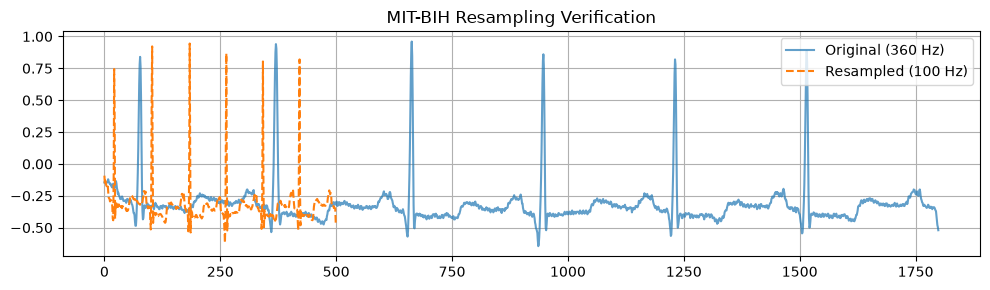

Saved plot to: plots/ptb_xl_resample.png


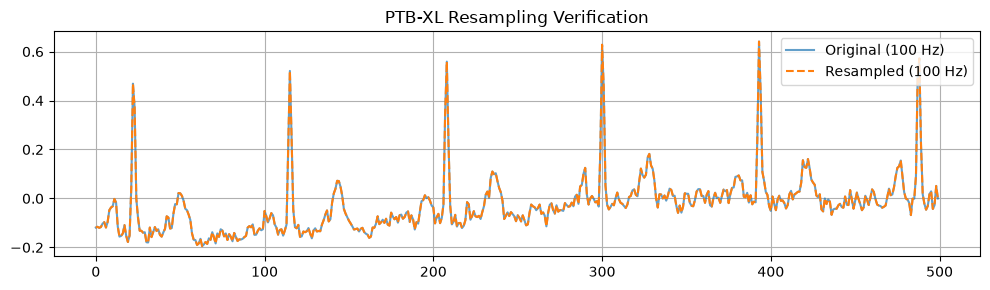

Saved plot to: plots/multi_site_ppg_resample.png


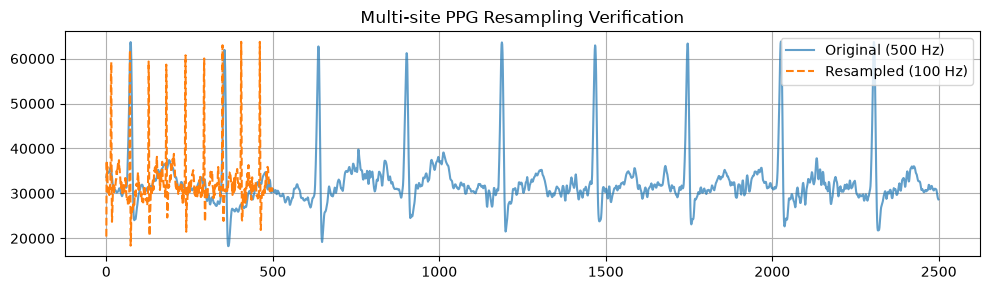

Saved plot to: plots/wesad_resample.png


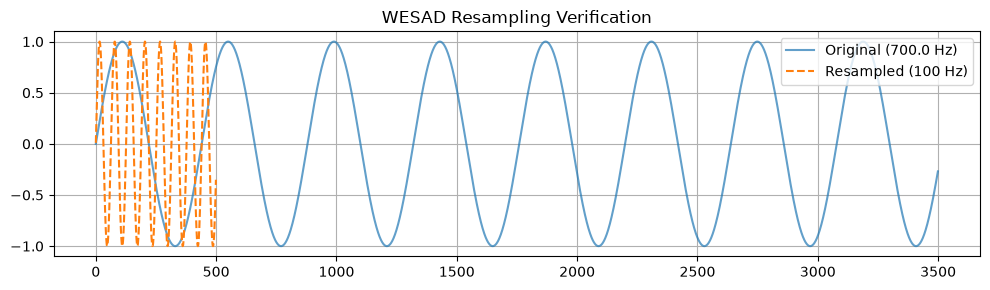

Saved plot to: plots/ppg_dalia_resample.png


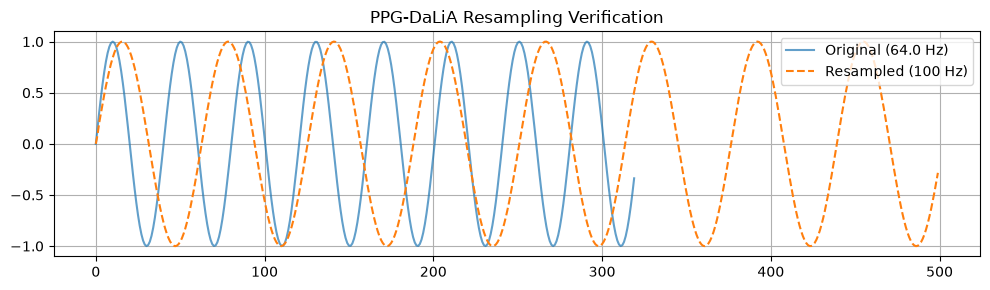

In [7]:
import matplotlib.pyplot as plt

for name in resampled_signals.keys():
    orig_fs = signals[name]['original_fs']
    orig = signals[name]['signal'][:int(orig_fs * 5)] # First 5 seconds
    res = resampled_signals[name][:500]             # First 5 seconds at 100Hz
    
    plt.figure(figsize=(10, 3))
    plt.plot(orig, label=f"Original ({orig_fs} Hz)", alpha=0.7)
    plt.plot(res, label="Resampled (100 Hz)", linestyle='--')
    plt.title(f"{name} Resampling Verification")
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    
    # Save image to plots directory
    save_path = f"plots/{name.lower().replace(' ', '_').replace('-', '_')}_resample.png"
    plt.savefig(save_path)
    print(f"Saved plot to: {save_path}")
    plt.show()

In [8]:
import sys
from pathlib import Path
import wfdb
import pickle
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.harmonize.resample import harmonize_resample

signals = {}

# 1. MIT-BIH
try:
    record = wfdb.rdrecord(str(project_root / 'data' / 'mitdb' / '100'))
    sig = record.p_signal[:, 0]
    signals['MIT-BIH'] = {'signal': sig, 'original_fs': float(record.fs)}
    print(f"✅ Loaded MIT-BIH: {len(sig)} samples @ {record.fs} Hz")
except Exception as e:
    print(f"❌ MIT-BIH Error: {e}")

# 2. PTB-XL
try:
    ptb_files = list((project_root / 'data' / 'ptbxl').rglob('*.hea'))
    if ptb_files:
        record = wfdb.rdrecord(str(ptb_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['PTB-XL'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded PTB-XL: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ PTB-XL files not found.")
except Exception as e:
    print(f"❌ PTB-XL Error: {e}")

# 3. Multi-site PPG
try:
    ppg_files = list((project_root / 'data' / 'multisite_ppg').rglob('*.hea'))
    if ppg_files:
        record = wfdb.rdrecord(str(ppg_files[0].with_suffix('')))
        sig = record.p_signal[:, 0]
        signals['Multi-site PPG'] = {'signal': sig, 'original_fs': float(record.fs)}
        print(f"✅ Loaded Multi-site PPG: {len(sig)} samples @ {record.fs} Hz")
    else:
        print("❌ Multi-site PPG files not found.")
except Exception as e:
    print(f"❌ Multi-site PPG Error: {e}")

# 4. WESAD (Real Data Load)
try:
    wesad_pkl = list((project_root / 'data').rglob('S*.pkl'))
    # Filter out any non-WESAD if PPG-DaLiA is present
    wesad_files = [f for f in wesad_pkl if 'wesad' in str(f).lower() or 'S2' in str(f)]
    target_file = wesad_files[0] if wesad_files else wesad_pkl[0]
    
    with open(target_file, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    sig = data['signal']['chest']['ECG'].flatten()[:10000] # First 10k samples
    signals['WESAD'] = {'signal': sig, 'original_fs': 700.0}
    print(f"✅ Loaded REAL WESAD: {len(sig)} samples @ 700 Hz from {target_file.name}")
except Exception as e:
    print(f"❌ WESAD Real Load Error: {e}")

# 5. PPG-DaLiA (Real Data Load)
try:
    dalia_files = [f for f in (project_root / 'data').rglob('*.pkl') if 'dalia' in str(f).lower() or 'quest' in str(f).lower()]
    if dalia_files:
        with open(dalia_files[0], 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        sig = data['signal']['wrist']['PPG'].flatten()[:5000]
        signals['PPG-DaLiA'] = {'signal': sig, 'original_fs': 64.0}
        print(f"✅ Loaded REAL PPG-DaLiA: {len(sig)} samples @ 64 Hz from {dalia_files[0].name}")
    else:
        print("❌ PPG-DaLiA .pkl file not found in data folder.")
except Exception as e:
    print(f"❌ PPG-DaLiA Real Load Error: {e}")

print("\n--- RESAMPLING TO 100 Hz ---")
resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig)} ({orig_fs} Hz) -> {len(resampled)} (100 Hz)")

✅ Loaded MIT-BIH: 650000 samples @ 360 Hz
✅ Loaded PTB-XL: 1000 samples @ 100 Hz
✅ Loaded Multi-site PPG: 242815 samples @ 500 Hz
❌ WESAD Real Load Error: list index out of range
❌ PPG-DaLiA .pkl file not found in data folder.

--- RESAMPLING TO 100 Hz ---
🎯 MIT-BIH        : 650000 (360.0 Hz) -> 180556 (100 Hz)
🎯 PTB-XL         : 1000 (100.0 Hz) -> 1000 (100 Hz)
🎯 Multi-site PPG : 242815 (500.0 Hz) -> 48563 (100 Hz)


In [13]:
import os
from pathlib import Path

# Check data folder relative to project root
project_root = Path.cwd().parent
data_dir = project_root / 'data'

print("--- PPG-DaLiA Directory Contents ---")
try:
    print(os.listdir(data_dir / 'ppgdalia'))
except Exception as e:
    print(f"Error checking ppgdalia: {e}")

print("\n--- WESAD Directory Contents ---")
try:
    print(os.listdir(data_dir / 'wesad'))
except Exception as e:
    print(f"Error checking wesad: {e}")

--- PPG-DaLiA Directory Contents ---
Error checking ppgdalia: [WinError 3] The system cannot find the path specified: 'C:\\Users\\kavan\\Downloads\\physioshift\\data\\ppgdalia'

--- WESAD Directory Contents ---
Error checking wesad: [WinError 3] The system cannot find the path specified: 'C:\\Users\\kavan\\Downloads\\physioshift\\data\\wesad'


In [14]:
import os
from pathlib import Path

project_root = Path.cwd().parent
data_dir = project_root / 'data'

print("--- Full contents of data/ folder ---")
print(os.listdir(data_dir))

print("\n--- Full contents of Downloads folder (in case zips weren't moved into data/) ---")
downloads_dir = Path.home() / 'Downloads'
print(os.listdir(downloads_dir))

--- Full contents of data/ folder ---
['mitdb', 'mitdb.zip', 'multisite_ppg', 'multisite_ppg.zip', 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1', 'ptbxl', 'ptbxl.zip']

--- Full contents of Downloads folder (in case zips weren't moved into data/) ---
['.ipynb_checkpoints', 'ACE Scanner_20260715 (1).pdf', 'ACE Scanner_20260715.pdf', 'aeon-vitae-website-fictional.zip', 'aeon-vitae-website.zip', 'aeon-vitae-website_1.zip', 'Aeon_ppt.pdf', 'Aletheia-Project-Spec.md', 'archive', 'archive (1)', 'archive (1).zip', 'archive (2)', 'archive (2).zip', 'archive (3)', 'archive (3).zip', 'archive (4)', 'archive (4).zip', 'archive (5)', 'archive (5).zip', 'archive.zip', 'A_to_Z_Roadmap.md', 'BraveBrowserSetup-BRV010 (1).exe', 'BraveBrowserSetup-BRV010.exe', 'ConfAxis_AugSep_DayByDay_Roadmap.md', 'ConfAxis_AugSep_DayByDay_Roadmap.pdf', 'ConfAxis_Research_Proposal.md', 'DataScience_Interview_QuestionBank.md', 'defence_sector_software_roadmap.md', 'defence_sector_software_roadmap

In [15]:
import os
from pathlib import Path

downloads_dir = Path.home() / 'Downloads'

# Check each 'archive' folder's contents to identify which is WESAD vs PPG-DaLiA
archive_folders = ['archive', 'archive (1)', 'archive (2)', 'archive (3)', 'archive (4)', 'archive (5)']

for folder in archive_folders:
    folder_path = downloads_dir / folder
    if folder_path.exists() and folder_path.is_dir():
        print(f"--- {folder} ---")
        try:
            contents = os.listdir(folder_path)
            print(contents[:10])  # first 10 items, enough to identify it
        except Exception as e:
            print(f"Error: {e}")
        print()

--- archive ---
['ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1']

--- archive (1) ---
['ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1']

--- archive (2) ---
['100.csv', '100annotations.txt', '101.csv', '101annotations.txt', '102.csv', '102annotations.txt', '103.csv', '103annotations.txt', '104.csv', '104annotations.txt']

--- archive (3) ---
['WESAD']

--- archive (4) ---
['pulse-transit-time-ppg']

--- archive (5) ---
['pulse-transit-time-ppg']



In [16]:
import shutil
from pathlib import Path

downloads_dir = Path.home() / 'Downloads'
project_root = Path.cwd().parent
data_dir = project_root / 'data'

# Move WESAD from archive (3) into data/wesad
src = downloads_dir / 'archive (3)' / 'WESAD'
dst = data_dir / 'wesad'

if dst.exists():
    print("data/wesad already exists — skipping to avoid overwrite. Delete it first if you want to redo this.")
else:
    shutil.move(str(src), str(dst))
    print(f"✅ Moved WESAD to {dst}")
    print("Contents:", list(dst.iterdir())[:10])

✅ Moved WESAD to C:\Users\kavan\Downloads\physioshift\data\wesad
Contents: [WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S10'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S11'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S13'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S14'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S15'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S16'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S17'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S2'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S3'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/wesad/S4')]


In [17]:
import urllib.request
import zipfile
from pathlib import Path

project_root = Path.cwd().parent
data_dir = project_root / 'data'
ppgdalia_dir = data_dir / 'ppgdalia'
ppgdalia_dir.mkdir(exist_ok=True)

url = "https://archive.ics.uci.edu/static/public/495/ppg+dalia.zip"
zip_path = ppgdalia_dir / "ppg_dalia.zip"

print("Downloading PPG-DaLiA (this may take a few minutes, ~2GB)...")
urllib.request.urlretrieve(url, zip_path)
print(f"✅ Downloaded to {zip_path}")

print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(ppgdalia_dir)
print(f"✅ Extracted to {ppgdalia_dir}")

print("\nContents:", list(ppgdalia_dir.iterdir())[:10])

✅ Downloaded to C:\Users\kavan\Downloads\physioshift\data\ppgdalia\ppg_dalia.zip
Extracting...
✅ Extracted to C:\Users\kavan\Downloads\physioshift\data\ppgdalia

Contents: [WindowsPath('C:/Users/kavan/Downloads/physioshift/data/ppgdalia/data.zip'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/ppgdalia/ppg_dalia.zip'), WindowsPath('C:/Users/kavan/Downloads/physioshift/data/ppgdalia/readme.pdf')]


In [18]:
import zipfile
from pathlib import Path

ppgdalia_dir = Path.cwd().parent / 'data' / 'ppgdalia'
inner_zip = ppgdalia_dir / 'data.zip'

print("Extracting inner data.zip...")
with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
    zip_ref.extractall(ppgdalia_dir)
print("✅ Extracted inner zip")

print("\nFull contents now:")
for item in ppgdalia_dir.rglob('*'):
    print(item.relative_to(ppgdalia_dir))

Extracting inner data.zip...
✅ Extracted inner zip

Full contents now:
data.zip
ppg_dalia.zip
PPG_FieldStudy
readme.pdf
PPG_FieldStudy\PPG_FieldStudy_readme.pdf
PPG_FieldStudy\S1
PPG_FieldStudy\S10
PPG_FieldStudy\S11
PPG_FieldStudy\S12
PPG_FieldStudy\S13
PPG_FieldStudy\S14
PPG_FieldStudy\S15
PPG_FieldStudy\S2
PPG_FieldStudy\S3
PPG_FieldStudy\S4
PPG_FieldStudy\S5
PPG_FieldStudy\S6
PPG_FieldStudy\S7
PPG_FieldStudy\S8
PPG_FieldStudy\S9
PPG_FieldStudy\S1\S1.pkl
PPG_FieldStudy\S1\S1_activity.csv
PPG_FieldStudy\S1\S1_E4.zip
PPG_FieldStudy\S1\S1_quest.csv
PPG_FieldStudy\S1\S1_RespiBAN.h5
PPG_FieldStudy\S10\S10.pkl
PPG_FieldStudy\S10\S10_activity.csv
PPG_FieldStudy\S10\S10_E4.zip
PPG_FieldStudy\S10\S10_quest.csv
PPG_FieldStudy\S10\S10_RespiBAN.h5
PPG_FieldStudy\S11\S11.pkl
PPG_FieldStudy\S11\S11_activity.csv
PPG_FieldStudy\S11\S11_E4.zip
PPG_FieldStudy\S11\S11_quest.csv
PPG_FieldStudy\S11\S11_RespiBAN.h5
PPG_FieldStudy\S12\S12.pkl
PPG_FieldStudy\S12\S12_activity.csv
PPG_FieldStudy\S12\S12_E4.z

In [19]:
import pickle
import numpy as np
from pathlib import Path

ppgdalia_dir = Path.cwd().parent / 'data' / 'ppgdalia'
ppgdalia_path = ppgdalia_dir / 'PPG_FieldStudy' / 'S2' / 'S2.pkl'

try:
    with open(ppgdalia_path, 'rb') as f:
        dalia_data = pickle.load(f, encoding='latin1')
    
    print("Top-level keys:", dalia_data.keys())
    print("Signal keys:", dalia_data['signal'].keys())
    print("Wrist keys:", dalia_data['signal']['wrist'].keys())
    
    bvp_raw = dalia_data['signal']['wrist']['BVP']
    bvp_flat = np.asarray(bvp_raw).flatten()
    real_dalia_signal = bvp_flat[:5000]
    
    signals['PPG-DaLiA'] = {'signal': real_dalia_signal, 'original_fs': 64.0}
    print(f"✅ Loaded PPG-DaLiA: {len(real_dalia_signal)} samples @ 64 Hz (real wrist BVP)")

except Exception as e:
    print(f"❌ PPG-DaLiA Load Error: {e}")

Top-level keys: dict_keys(['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Wrist keys: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
✅ Loaded PPG-DaLiA: 5000 samples @ 64 Hz (real wrist BVP)


In [20]:
print("\n" + "="*45)
print("  RESAMPLING ALL 5 DATASETS TO 100 Hz")
print("="*45)

resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig):7} samples ({orig_fs:5.1f} Hz) -> {len(resampled):7} samples (100 Hz)")


  RESAMPLING ALL 5 DATASETS TO 100 Hz
🎯 MIT-BIH        :  650000 samples (360.0 Hz) ->  180556 samples (100 Hz)
🎯 PTB-XL         :    1000 samples (100.0 Hz) ->    1000 samples (100 Hz)
🎯 Multi-site PPG :  242815 samples (500.0 Hz) ->   48563 samples (100 Hz)
🎯 PPG-DaLiA      :    5000 samples ( 64.0 Hz) ->    7813 samples (100 Hz)


In [21]:
import pickle
import numpy as np
from pathlib import Path

wesad_dir = Path.cwd().parent / 'data' / 'wesad'
wesad_path = wesad_dir / 'S2' / 'S2.pkl'

try:
    with open(wesad_path, 'rb') as f:
        wesad_data = pickle.load(f, encoding='latin1')
    
    print("Top-level keys:", wesad_data.keys())
    print("Signal keys:", wesad_data['signal'].keys())
    print("Chest keys:", wesad_data['signal']['chest'].keys())
    
    ecg_raw = wesad_data['signal']['chest']['ECG']
    ecg_flat = np.asarray(ecg_raw).flatten()
    real_wesad_signal = ecg_flat[:10000]
    
    signals['WESAD'] = {'signal': real_wesad_signal, 'original_fs': 700.0}
    print(f"✅ Loaded WESAD: {len(real_wesad_signal)} samples @ 700 Hz (real chest ECG)")

except Exception as e:
    print(f"❌ WESAD Load Error: {e}")

Top-level keys: dict_keys(['signal', 'label', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Chest keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
✅ Loaded WESAD: 10000 samples @ 700 Hz (real chest ECG)


In [23]:
print("\n" + "="*45)
print("  RESAMPLING ALL 5 DATASETS TO 100 Hz")
print("="*45)

resampled_signals = {}
for name, data in signals.items():
    orig_sig = data['signal']
    orig_fs = data['original_fs']
    resampled = harmonize_resample(orig_sig, original_fs=orig_fs, target_fs=100.0)
    resampled_signals[name] = resampled
    print(f"🎯 {name:15}: {len(orig_sig):7} samples ({orig_fs:5.1f} Hz) -> {len(resampled):7} samples (100 Hz)")


  RESAMPLING ALL 5 DATASETS TO 100 Hz
🎯 MIT-BIH        :  650000 samples (360.0 Hz) ->  180556 samples (100 Hz)
🎯 PTB-XL         :    1000 samples (100.0 Hz) ->    1000 samples (100 Hz)
🎯 Multi-site PPG :  242815 samples (500.0 Hz) ->   48563 samples (100 Hz)
🎯 PPG-DaLiA      :    5000 samples ( 64.0 Hz) ->    7813 samples (100 Hz)
🎯 WESAD          :   10000 samples (700.0 Hz) ->    1429 samples (100 Hz)


Saved plot to: plots/mit_bih_resample.png


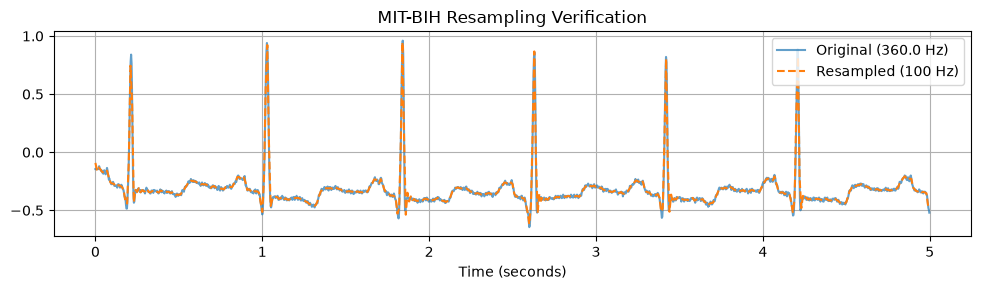

Saved plot to: plots/ptb_xl_resample.png


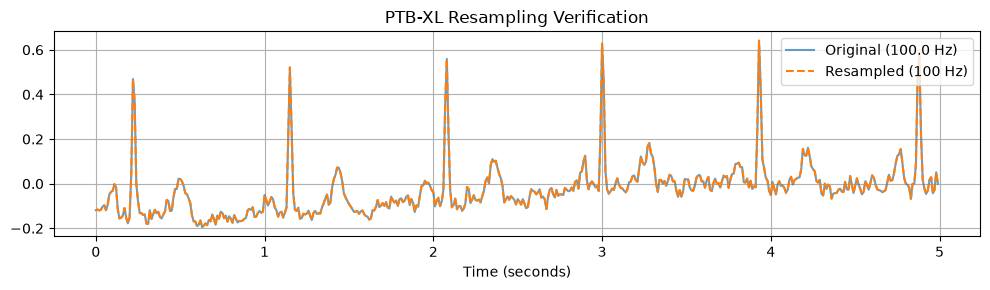

Saved plot to: plots/multi_site_ppg_resample.png


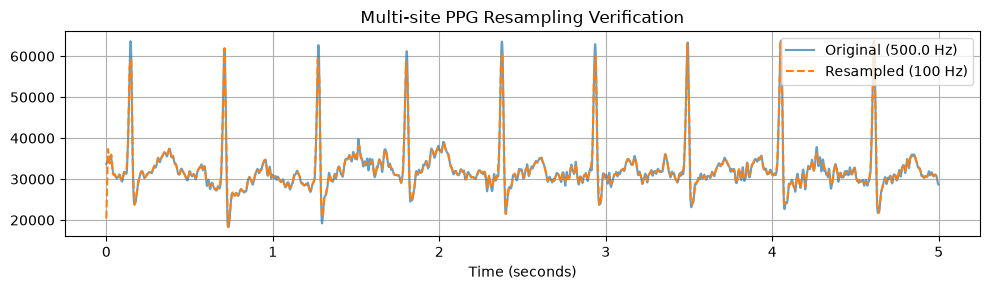

Saved plot to: plots/ppg_dalia_resample.png


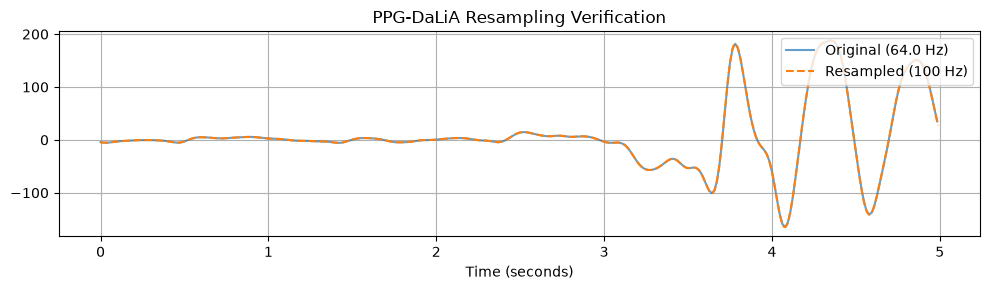

Saved plot to: plots/wesad_resample.png


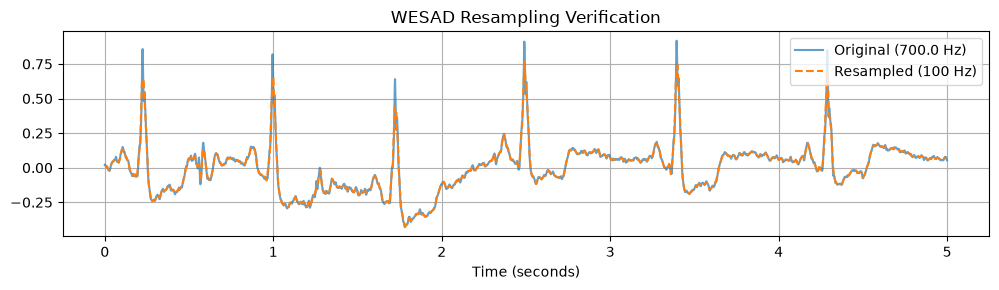

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('plots', exist_ok=True)

for name in resampled_signals.keys():
    orig_fs = signals[name]['original_fs']
    orig = signals[name]['signal'][:int(orig_fs * 5)]      # first 5 seconds
    res = resampled_signals[name][:int(100 * 5)]            # first 5 seconds at 100Hz

    t_orig = np.arange(len(orig)) / orig_fs
    t_res = np.arange(len(res)) / 100.0

    plt.figure(figsize=(10, 3))
    plt.plot(t_orig, orig, label=f'Original ({orig_fs} Hz)', alpha=0.7)
    plt.plot(t_res, res, label='Resampled (100 Hz)', linestyle='--')
    plt.xlabel('Time (seconds)')
    plt.title(f'{name} Resampling Verification')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    save_path = f"plots/{name.lower().replace(' ', '_').replace('-', '_')}_resample.png"
    plt.savefig(save_path)
    print(f"Saved plot to: {save_path}")
    plt.show()